# 03 — Evaluation: IC and long-short portfolios

R² is a harsh metric for returns. Quants usually ask two other questions:
1. **Information Coefficient (IC):** each month, is the *ranking* of predictions correlated with the ranking of realized returns? A mean IC of 0.02–0.05 with a t-stat above 2 is considered a real signal.
2. **Can you trade it?** Each month, buy the top 20% of stocks by prediction and short the bottom 20% (equal weights), paying 10 bps per trade.

All logic lives in `src/evaluation.py`.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import REPORTS_DIR
from src.evaluation import ic_series, ic_summary, quintile_returns, long_short, performance

panel = pd.read_pickle("../data/processed/panel.pkl")
preds = pd.read_pickle("../data/processed/predictions.pkl")
test = panel.loc[preds.index]

## 1. Information Coefficient

In [2]:
ic = ic_series(preds, test["fwd_ret_xs"])
ic_table = ic_summary(ic)
ic_table.round(3)

,mean_IC,t_stat,hit_rate,IC_IR_ann,months
Momentum (no model),0.010,0.440,0.511,0.129,139
Ridge,-0.019,-0.916,0.489,-0.269,139
GBM,0.015,1.048,0.561,0.308,139
Neural net,-0.000,-0.014,0.511,-0.004,139


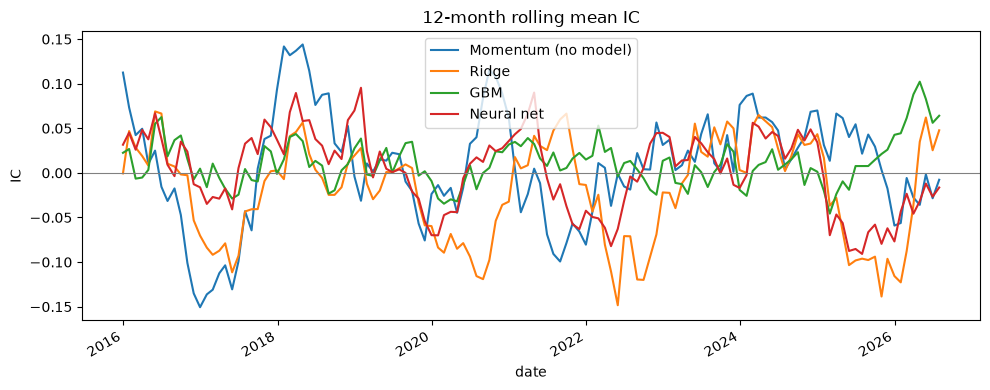

In [3]:
ax = ic.rolling(12).mean().plot(figsize=(10, 4), title="12-month rolling mean IC")
ax.axhline(0, color="grey", lw=0.8); ax.set_ylabel("IC")
plt.tight_layout(); plt.savefig(REPORTS_DIR / "rolling_ic.png", dpi=150); plt.show()

## 2. Do higher predictions mean higher returns?
If a signal works, average returns should rise from quintile 1 (lowest prediction) to quintile 5.

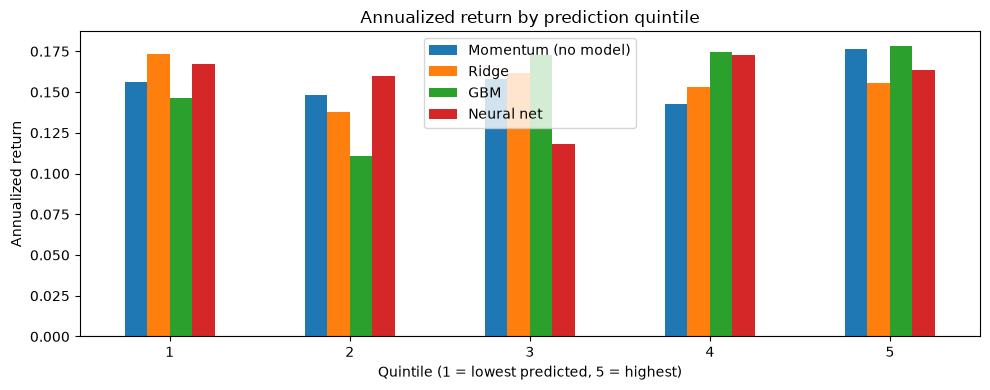

,Momentum (no model),Ridge,GBM,Neural net
q,,,,
1,15.64,17.33,14.62,16.72
2,14.82,13.77,11.06,16.01
3,15.81,16.19,17.25,11.79
4,14.24,15.30,17.43,17.29
5,17.61,15.57,17.83,16.33


In [4]:
q_means = pd.DataFrame({m: quintile_returns(preds[m], test["fwd_ret"]).mean() * 12 for m in preds.columns})
ax = q_means.plot.bar(figsize=(10, 4), rot=0, title="Annualized return by prediction quintile")
ax.set_xlabel("Quintile (1 = lowest predicted, 5 = highest)"); ax.set_ylabel("Annualized return")
ax.axhline(0, color="grey", lw=0.8)
plt.tight_layout(); plt.savefig(REPORTS_DIR / "quintiles.png", dpi=150); plt.show()
(q_means * 100).round(2)

## 3. Long-short portfolios (10 bps per trade)
Benchmark: **equal-weight long-only** portfolio of all 52 stocks.

In [5]:
ls_rets, turnovers = {}, {}
for m in preds.columns:
    ls_rets[m], turnovers[m] = long_short(preds[m], test["fwd_ret"], cost_bps=10)
ls_rets = pd.DataFrame(ls_rets)
equal_weight = test["fwd_ret"].groupby(level="date").mean().reindex(ls_rets.index)

perf = pd.DataFrame({m: performance(ls_rets[m]) for m in ls_rets}).T
perf["turnover_per_leg"] = [turnovers[m].mean() for m in ls_rets]
perf.loc["Equal weight (long only)"] = performance(equal_weight)
perf.round(3)

,ann_return,ann_vol,sharpe,max_drawdown,months,turnover_per_leg
Momentum (no model),0.009,0.187,0.046,-0.445,139.0,0.232
Ridge,-0.034,0.194,-0.175,-0.582,139.0,0.340
GBM,0.010,0.138,0.070,-0.339,139.0,0.469
Neural net,-0.027,0.118,-0.229,-0.341,139.0,0.478
Equal weight (long only),0.157,0.149,1.053,-0.215,139.0,NaN


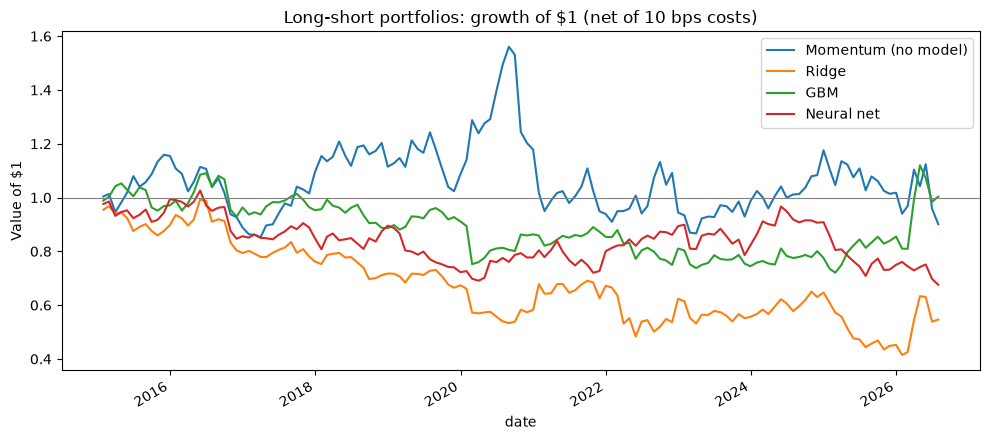

In [6]:
wealth = (1 + ls_rets).cumprod()
ax = wealth.plot(figsize=(10, 4.5), title="Long-short portfolios: growth of $1 (net of 10 bps costs)")
ax.axhline(1, color="grey", lw=0.8); ax.set_ylabel("Value of $1")
plt.tight_layout(); plt.savefig(REPORTS_DIR / "long_short.png", dpi=150); plt.show()

## 4. Year by year

In [7]:
yearly_ic = ic.groupby(ic.index.year).mean()
yearly_ic.round(3)

,Momentum (no model),Ridge,GBM,Neural net
date,,,,
2015,0.112,-0.001,0.023,0.032
2016,-0.151,-0.070,0.005,-0.016
2017,0.093,0.003,-0.001,0.037
2018,-0.004,0.020,0.028,0.070
2019,-0.024,-0.060,-0.009,-0.070
2020,0.062,-0.032,0.032,0.036
2021,-0.080,-0.014,0.015,-0.042
2022,0.031,-0.022,0.014,0.045
2023,0.076,0.003,-0.019,-0.017


## 5. Key numbers (text summary)

In [8]:
print("IC summary:")
print(ic_table.round(3).to_string())
print("\nAnnualized return by quintile (%):")
print((q_means * 100).round(2).to_string())
print("\nLong-short performance (10 bps costs):")
print(perf.round(3).to_string())
print("\nMean IC by year:")
print(yearly_ic.round(3).to_string())
ic_table.round(4).to_csv(REPORTS_DIR / "ic_summary.csv")
perf.round(4).to_csv(REPORTS_DIR / "long_short_performance.csv")

IC summary:
                     mean_IC  t_stat  hit_rate  IC_IR_ann  months
Momentum (no model)    0.010   0.440     0.511      0.129     139
Ridge                 -0.019  -0.916     0.489     -0.269     139
GBM                    0.015   1.048     0.561      0.308     139
Neural net            -0.000  -0.014     0.511     -0.004     139

Annualized return by quintile (%):
   Momentum (no model)  Ridge    GBM  Neural net
q                                               
1                15.64  17.33  14.62       16.72
2                14.82  13.77  11.06       16.01
3                15.81  16.19  17.25       11.79
4                14.24  15.30  17.43       17.29
5                17.61  15.57  17.83       16.33

Long-short performance (10 bps costs):
                          ann_return  ann_vol  sharpe  max_drawdown  months  turnover_per_leg
Momentum (no model)            0.009    0.187   0.046        -0.445   139.0             0.232
Ridge                         -0.034    0.194  -0.1

## Takeaways

- **No statistically significant signal.** Best mean IC is GBM at 0.015 (t = 1.05, positive in 56% of months); momentum 0.010 (t = 0.44); neural net 0.000; Ridge −0.019. None clears t = 2.
- **Quintiles are not monotonic**, except loosely for GBM (Q1 14.6% → Q5 17.8% per year).
- **Long-short portfolios earn nothing after 10 bps costs** (Sharpe −0.23 to +0.07), while an equal-weight long-only portfolio of the 52 stocks returned 15.7%/yr (Sharpe 1.05), partly due to survivorship bias.
- **Interpretation:** for heavily-traded mega-caps, public price/volume characteristics carry little predictive power for next-month relative returns, consistent with research showing such anomalies are concentrated in smaller stocks and weak for momentum since 2010.